In [126]:
import numpy as np
import random as rand
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
import os
import json
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
models_path = os.path.join(project_root, "Models")
sys.path.append(models_path)
from ELO import Elo

In [127]:
# Get project root (2 levels up from current notebook location)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
 
# Define key directories
models_dir = os.path.join(project_root, 'Models')
trained_models_dir = os.path.join(project_root, 'Trained_Models')
simulated_data_dir = os.path.join(project_root, 'Simulated_Data')
results_dir = os.path.join(project_root, 'Results')
 
# Add Models to Python path
if models_dir not in sys.path:
    sys.path.insert(0, models_dir)
 
# Verify paths exist
print("=" * 60)
print("PROJECT PATHS VERIFICATION")
print("=" * 60)
print(f"Project Root:      {project_root}")
print(f"Models Dir:        {models_dir} ✓" if os.path.exists(models_dir) else f"Models Dir:        {models_dir} ✗")
print(f"Trained Models:    {trained_models_dir} ✓" if os.path.exists(trained_models_dir) else f"Trained Models:    {trained_models_dir} ✗")
print(f"Simulated Data:    {simulated_data_dir} ✓" if os.path.exists(simulated_data_dir) else f"Simulated Data:    {simulated_data_dir} ✗")
print(f"Results Dir:       {results_dir} ✓" if os.path.exists(results_dir) else f"Results Dir:       {results_dir} ✗")
print("=" * 60)

PROJECT PATHS VERIFICATION
Project Root:      /Users/GraceCeline/Bachelorarbeit
Models Dir:        /Users/GraceCeline/Bachelorarbeit/Models ✓
Trained Models:    /Users/GraceCeline/Bachelorarbeit/Trained_Models ✓
Simulated Data:    /Users/GraceCeline/Bachelorarbeit/Simulated_Data ✓
Results Dir:       /Users/GraceCeline/Bachelorarbeit/Results ✓


In [128]:
def load_testing_data(scenario, split):
    base_path = os.path.join(project_root, 'Simulated_Data')
    
    filename = f"scenario_{scenario}_{split}_data.csv"
    filepath = os.path.join(base_path, filename)
    
    return pd.read_csv(filepath)

In [129]:
def construct_training_data(df, initial_id, last_id, num_task):
    X = []
    Y = []

    task_ids    = sorted(df['task'].unique())
    task_to_idx = {task: idx for idx, task in enumerate(task_ids)}

    for student_id in range(initial_id, last_id):
        student_df = df[df['student_id'] == student_id].reset_index(drop=True)
        X_student = [torch.zeros(num_task * 2)] 
        Y_student = []

        for _, row in student_df.iterrows():
            task_id = row['task']
            success = row['success']
            y_student = torch.tensor([int(task_id), float(success)])
            Y_student.append(y_student)

            x_student = torch.zeros(num_task *2)
            if success == 1:
                x_student[task_id] = 1
            else:
                x_student[task_id + num_task] = 1
            X_student.append(x_student)
        
        X_student = torch.stack(X_student)
        Y_student = torch.stack(Y_student)
        X.append(X_student)
        Y.append(Y_student)

    return X, Y


In [130]:
import torch
import random

class DKT(torch.nn.Module):
    def __init__(self, num_exercises, num_neurons = 32, C = 1000., num_epochs = 5000, learning_rate = 1E-2):
        super(DKT, self).__init__()
        self.num_exercises_ = num_exercises
        self.num_neurons_   = num_neurons
        self.C_             = C
        self.num_epochs_    = num_epochs
        self.learning_rate_ = learning_rate
        self.gru_           = torch.nn.GRU(self.num_exercises_ * 2, self.num_neurons_) # this is f
        self.out_           = torch.nn.Linear(self.num_neurons_, self.num_exercises_) # this is g

    def forward(self, X):
        H, _ = self.gru_(X)
        return self.out_(H)

    """
    Scores the accuracy of this model.
    """
    def score(self, X, Y):
        num_attempts  = 0
        num_successes = 0
        for i in range(len(X)):
            Yi = Y[i]
            Logits = self.forward(X[i])
            selected_logits = Logits.gather(
                                  1, Yi[:,0].long().unsqueeze(1)
                              ).squeeze(1)
            probs = torch.sigmoid(selected_logits)
            preds = (probs >= 0.5).float()

            num_successes += (preds == Yi[:,1]).sum().item()
            num_attempts += len(Yi[:,1])
        return num_successes / num_attempts


    """
    Fits this model to the given data matrix.

    Parameters
    ----------
    X: list
        A list of feature matrices, one per student.
    Y: list
        A list of target matrices, one per student.

    """
    def fit(self, X, Y):
        # initialize optimizer
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate_, weight_decay = 1. / self.C_)
        self.train()
        # start training
        for epoch in range(self.num_epochs_):
            # re-set the current gradient to zero
            optimizer.zero_grad()
            # get a random student index
            i  = random.randrange(len(X))
            Xi = X[i]
            Yi = Y[i]
            # compute the Logits
            Logits = self.forward(Xi)
            selected_logits = Logits.gather(
                                  1, Yi[:,0].long().unsqueeze(1)
                              ).squeeze(1) # Choose the index of the executed task, and only take the logit of this task for every time step
            # compute the loss
            loss = torch.nn.functional.binary_cross_entropy_with_logits(selected_logits, Yi[:,1].float())
            # report the loss
            if (epoch+1) % 1000 == 0:
                print('epoch %d: loss %g' % (epoch+1, loss.item()))
            # compute the gradient
            loss.backward()
            # apply the optimizer
            optimizer.step()

        return self

In [131]:
def load_model(scenario_id, num_exercises, base_dir=None, device=None):
    """
    Load a saved DKT model checkpoint for testing.

    Args:
        scenario_id : scenario identifier (e.g. 1–6, or a string name)
        base_dir    : optional override for the Trained_Models folder path
        device      : torch.device to load onto ('cpu', 'cuda', etc.)
                      defaults to cuda if available, else cpu

    Returns:
        model       : DKT model in eval() mode, ready for inference
        checkpoint  : full checkpoint dict (contains hyperparams if needed)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if base_dir is None:
        base_dir = os.path.join(project_root, 'Trained_Models')

    model_path = os.path.join(base_dir, f'DKT_model_scenario_{scenario_id}.pth')

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"No saved model found for scenario {scenario_id} at:\n  {model_path}")

    checkpoint = torch.load(model_path, map_location=device)

    # Rebuild the architecture from saved constructor args
    model = DKT(
        num_exercises = num_exercises,
        num_neurons   = checkpoint['num_neurons'],
        C             = checkpoint['C'],
        num_epochs    = checkpoint['num_epochs'],
        learning_rate = checkpoint['learning_rate'],
    )

    # Load the trained weights
    model.load_state_dict(checkpoint['model_state'])
    model.to(device)
    model.eval() # Set model to evaluation mode

    return model, checkpoint

In [132]:
def skill_display(optimal_skills):
    x_values = list(range(1, len(optimal_skills) + 1))
    # Convert data for plotting: organize skill levels into separate lists for each skill
    paired_lists = [
        [optimal_skills[j][i] for j in range(len(optimal_skills))]
        for i in range(len(optimal_skills[0]))
        ]
    num_lines = len(paired_lists) # Number of skills to plot
    colors = plt.cm.viridis(np.linspace(0, 1, num_lines)) # Generate a color palette
    plt.figure(figsize=(8, 4))
    plt.title("Highest learning gain")
    # Plot each skill level over time
    for i in range(num_lines):
        plt.plot(paired_lists[i], linestyle='-', color=colors[i], label=f'Skill {i+1}')

    plt.xlabel('Time')
    plt.ylabel('Skill Level')
    plt.legend()
    plt.grid(True)
    plt.show()

In [133]:
def calculate_p_op(n):
    return 0.5 - 1 / (2 * (n - 1))
    # Let n be the ratio of k_success and k_fail

In [134]:
def steps_to_mastery(X, Y, dkt_model, initial_skill, q_matrix, difficulty, depends, k_success, k_fail, p_op): 
    results_dkt = [] 
    DKT_Data = [] 
    
    for i in range(len(X)): 
        skill_levels = initial_skill.copy() # reset per student 
        X_student = torch.zeros((1, num_tasks * 2), dtype=torch.float32) 
        reached_step = None 
        step = 0 
        data_for_student = [] 
        skill_history = [initial_skill.tolist()] 
        
        while np.any(skill_levels <= 1.5) and step < 30: # ← safety cap 
            step += 1 
            with torch.no_grad(): 
                prob = torch.sigmoid(dkt_model(X_student))[-1] 
            uncertainty = torch.abs(prob - p_op) 
            task = torch.argmin(uncertainty).item() 
            updated_skill, correctness = Elo.skill_update( difficulty[task], skill_levels, q_matrix[:, task], depends, k_success, k_fail ) 
            skill_levels = updated_skill 
            skill_history.append(skill_levels.tolist()) 
            data_for_student.append((task, correctness)) 
            new_row = torch.zeros((1, num_tasks * 2), dtype=torch.float32) 
            if correctness == 1: 
                    new_row[0, task] = 1.0 
            else: 
                    new_row[0, task + num_tasks] = 1.0 
            X_student = torch.cat([X_student, new_row]) 
            
            if reached_step is None and np.all(skill_levels >= 1.5): 
                reached_step = step 
        
        if reached_step is None:
            reached_step = 30
                
        results_dkt.append({ "student": i + 1, "steps_to_mastery": reached_step}) 
        DKT_Data.append(data_for_student) 
        last_skill_history = skill_history 
    average_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].mean() 
    std_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].std()
    skill_history_array = np.array(last_skill_history) 
    return average_steps, std_steps, skill_history_array

In [135]:
def run_unoptimized(n, p_op=0.4):
            results = []
            average_step_lower_p_op, rand_plot_lower_p_op = steps_to_mastery(X_test, Y_test, dkt, init_skill_level.copy(), q_matrix, difficulty_level, depends, 1, 0.167, p_op) # pop 0
            average_step_normal_p_op, rand_plot_normal_p_op  = steps_to_mastery(X_test, Y_test, dkt, init_skill_level.copy(), q_matrix, difficulty_level, depends, 1, 0.25, p_op)
            average_step_higher_p_op, rand_plot_higher_p_op = steps_to_mastery(X_test, Y_test, dkt, init_skill_level.copy(), q_matrix, difficulty_level, depends, 1, 0.5, p_op)
                
            results.append({
                                "scenario":            scenario_id,
                                "avg_steps_0.0":       average_step_lower_p_op,
                                "avg_steps_0.33":       average_step_normal_p_op,
                                "avg_steps_0.4":       average_step_higher_p_op,
            })
                        
            results_table = pd.DataFrame(results)
        
            steps      = range(rand_plot_higher_p_op.shape[0])

            print(f"PLOT FOR p_op = {p_op}")
            print(results_table)


            fig, axes = plt.subplots(1, 3, figsize=(16, 5))

            data = [(rand_plot_lower_p_op, f'k- = 0.167', 'o'),
                    (rand_plot_normal_p_op, f'k- = 0.25', 's'),
                    (rand_plot_higher_p_op, f'k- = 0.5', '^')]
            
            colors = [('blue', 'cyan'), ('orange', 'green'), ('purple', 'brown')]
            
            for ax, (rand_plot, title, marker), (c1, c2) in zip(axes, data, colors):
                steps = range(rand_plot.shape[0])
                ax.plot(steps, rand_plot[:, 0], marker=marker, label='Skill 1', linewidth=2, color=c1)
                ax.plot(steps, rand_plot[:, 1], marker=marker, label='Skill 2', linewidth=2, color=c2)
                ax.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5)
                ax.set_title(title, fontweight='bold')
                ax.set_xlabel('Step')
                ax.set_ylabel('Skill Level')
                ax.legend()
                ax.grid(True, alpha=0.3)
            
            fig.suptitle(f'Skill Mastery Progression — Scenario {scenario_id} p optimal {p_op}', fontsize=14, fontweight='bold', y=1.02)
            plt.tight_layout()
            plt.show()

In [136]:
def optimized_steps_to_mastery(X, Y, dkt_model, num_tasks, initial_skill, q_matrix, difficulty, depends, k_success, n): # n is ratio from k+ to k-
    results_dkt      = []
    DKT_Data         = []
    k_fail = 1/n
    p_op = calculate_p_op(n)
    print(f"Adjusted kappa with k- being {k_fail}")

    for i in range(len(X)):
        skill_levels     = initial_skill.copy()   # reset per student
        X_student        = torch.zeros((1, num_tasks * 2), dtype=torch.float32)
        reached_step     = None
        step             = 0
        data_for_student = []
        skill_history    = [initial_skill.tolist()]

        while np.any(skill_levels <= 1.5) and step < 30:  # ← safety cap
            step += 1

            with torch.no_grad():
                prob      = torch.sigmoid(dkt_model(X_student))[-1]
            uncertainty   = torch.abs(prob - p_op)
            task          = torch.argmin(uncertainty).item()

            updated_skill, correctness = Elo.skill_update(
                difficulty[task], skill_levels, q_matrix[:, task], depends, k_success, k_fail
            )

            if i == 0:
                # print(f"[Student 0]: Selected Task {task} Knowledge state: {updated_skill}, Response: {correctness} prob {prob[task]}")
                print(f"[Student 0]: Selected Task {task} prob {prob[task]} prob everything {prob}")
            skill_levels = updated_skill
            skill_history.append(skill_levels.tolist())
            data_for_student.append((task, correctness))

            new_row = torch.zeros((1, num_tasks * 2), dtype=torch.float32)
            if correctness == 1:
                new_row[0, task] = 1.0
            else:
                new_row[0, task + num_tasks] = 1.0
            X_student = torch.cat([X_student, new_row])

            if reached_step is None and np.all(skill_levels >= 1.5):
                reached_step = step
        
        if reached_step is None:
            reached_step = 30        # only triggers if mastery was NEVER reached
        results_dkt.append({
            "student":           i + 1,
            "steps_to_mastery":  reached_step,
            "p_op":         p_op
        })
        DKT_Data.append(data_for_student)
        last_skill_history = skill_history

    average_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].mean()
    std_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].std(ddof=0)
    skill_history_array = np.array(last_skill_history)
    return average_steps, std_steps, skill_history_array, p_op

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_optimization(num_tasks):
    n_values = [2, 4, 6]
    results = []
    plot_data_by_n = {}
    # Test each n value
    all_rows = []
    row = {"scenario": scenario_id}
    for n in n_values:

        # Get optimal p_op
        avg_steps_opt, std_steps_opt, rand_plot_opt, p_op_opt = optimized_steps_to_mastery(
            X_test, Y_test, dkt, num_tasks, init_skill_level.copy(), 
            q_matrix, difficulty_level, depends, 1, n
        )

        p_op_label = round(p_op_opt, 2)
        row[f"p_op_{p_op_label}_mean"] = avg_steps_opt
        row[f"p_op_{p_op_label}_std"]  = std_steps_opt

        # Test p_op = 0.0
        avg_steps_00, std_steps_00, rand_plot_00 = steps_to_mastery(
            X_test, Y_test, dkt, init_skill_level.copy(), 
            q_matrix, difficulty_level, depends, 1, 1/n, 0.0
        )

        # Test p_op = 0.5
        avg_steps_05, std_steps_05, rand_plot_05 = steps_to_mastery(
            X_test, Y_test, dkt, init_skill_level.copy(), 
            q_matrix, difficulty_level, depends, 1, 1/n, 0.5
        )
        
        # Store results for table
        results.append({
            "scenario": scenario_id,
            "n": n,
            "p_op_optimal": p_op_opt,
            "steps_optimal_mean": avg_steps_opt,
            "steps_optimal_std": std_steps_opt,
            "steps_p00_mean": avg_steps_00,
            "steps_p00_std": std_steps_00,
            "steps_p05_mean": avg_steps_05,
            "steps_p05_std": std_steps_05,
        })
        # Store plot data
        plot_data_by_n[n] = {
            "p_op_opt": p_op_opt,
            "rand_plot_opt": rand_plot_opt,
            "rand_plot_00": rand_plot_00,
            "rand_plot_05": rand_plot_05,
        }
    # Create results dataframe
    df_results = pd.DataFrame(results)
    # df_results.to_csv(f'Results/dkt_results_scenario_{scenario_id}.csv', index=False)

    all_rows.append(row)
    # pd.DataFrame(all_rows).to_csv(f"../../Results/dkt_results_scenario_{scenario_id}.csv", index=False)
    
    # Plot 3 subplots (one for each n) - reuse stored data
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    legend_labels = ['Optimal (Skill 0)', 'p_op=0.00 (Skill 0)', 'p_op=0.50 (Skill 0)',
                      'Optimal (Skill 1)', 'p_op=0.00 (Skill 1)', 'p_op=0.50 (Skill 1)']
    for idx, n in enumerate(n_values):
        ax = axes[idx]
        data = plot_data_by_n[n]
        
        steps_opt = range(data['rand_plot_opt'].shape[0])
        steps_00 = range(data['rand_plot_00'].shape[0])
        steps_05 = range(data['rand_plot_05'].shape[0])
        
        # Skill 0 (column 0)
        ax.plot(steps_opt, data['rand_plot_opt'][:, 0], marker='o', label=f'Optimal p_op={data["p_op_opt"]:.2f}', linewidth=2, color='blue')
        ax.plot(steps_00, data['rand_plot_00'][:, 0], marker='s', label='p_op=0.00', linewidth=2, color='orange')
        ax.plot(steps_05, data['rand_plot_05'][:, 0], marker='^', label='p_op=0.50', linewidth=2, color='purple')
        
        # Skill 1 (column 1) - dashed lines
        ax.plot(steps_opt, data['rand_plot_opt'][:, 1], marker='o', linestyle='--', linewidth=2, color='blue', alpha=0.6)
        ax.plot(steps_00, data['rand_plot_00'][:, 1], marker='s', linestyle='--', linewidth=2, color='orange', alpha=0.6)
        ax.plot(steps_05, data['rand_plot_05'][:, 1], marker='^', linestyle='--', linewidth=2, color='purple', alpha=0.6)

        if data['rand_plot_opt'].shape[1] > 2:
            ax.plot(steps_opt, data['rand_plot_opt'][:, 2], marker='o', linestyle=':', linewidth=2, color='blue', alpha=0.4)
            ax.plot(steps_00, data['rand_plot_00'][:, 2], marker='s', linestyle=':', linewidth=2, color='orange', alpha=0.4)
            ax.plot(steps_05, data['rand_plot_05'][:, 2], marker='^', linestyle=':', linewidth=2, color='purple', alpha=0.4)
            legend_labels += ['Optimal (Skill 2)', 'p_op=0.00 (Skill 2)', 'p_op=0.50 (Skill 2)']
        
        ax.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5)
        ax.set_title(f'n={n}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Step')
        ax.set_ylabel('Skill Level')
        ax.legend(legend_labels + ['Mastery threshold'])
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'DKT Task Selection Comparison — Scenario {scenario_id}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    # plt.savefig(f'Results/dkt_results_scenario_{scenario_id}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # return df_results

# Optimize DKT

In [138]:
with open('../../elo_variable.json', 'r') as Elo_Data:
    elo_data = json.load(Elo_Data)

print(elo_data)

{'globals': {'students': 500, 'init_skill_level': [0.0, 0.0], 'k_success': 1, 'k_fail': 0.5}, 'scenarios': [{'id': 1, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 0], [0, 1]], 'difficulty_level': [1, 1], 'depends': [-1, -1]}, {'id': 2, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 1], [1, 1]], 'difficulty_level': [0, 1], 'depends': [-1, -1]}, {'id': 3, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0], [0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1], 'depends': [-1, -1, -1, -1]}, {'id': 4, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1], [0, 1, 1, 1]], 'difficulty_level': [1, 1, 0, 1], 'depends': [-1, -1, -1, -1]}, {'id': 5, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1, 0, 1], [0, 1, 1, 0, 1, 1]], 'difficulty_level': [0, 0, 0, 1, 1, 1], 'depends': [-1, -1, -1, -1, -1, -1]}, {'id': 6, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0, 1, 0], [0, 1, 0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1, 2, 2], 'depends': [-1, -1, -1, -1, -1, -1]}

In [139]:
all_data = {}

level_skill   = [] 
mastery_level = 1.5
i = 0

global_values = elo_data["globals"]
scenarios = elo_data["scenarios"]

students          = global_values["students"]
# init_skill_level  = np.array([0.0])

-------------- RESULTS FOR SCENARIO 1------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 1 prob 0.30204665660858154 prob everything tensor([0.3118, 0.3020])
[Student 0]: Selected Task 0 prob 0.2889600396156311 prob everything tensor([0.2890, 0.3440])
[Student 0]: Selected Task 1 prob 0.3229745030403137 prob everything tensor([0.4362, 0.3230])
[Student 0]: Selected Task 1 prob 0.37709927558898926 prob everything tensor([0.4171, 0.3771])
[Student 0]: Selected Task 0 prob 0.4056747853755951 prob everything tensor([0.4057, 0.4207])
[Student 0]: Selected Task 1 prob 0.4296155571937561 prob everything tensor([0.4819, 0.4296])
[Student 0]: Selected Task 1 prob 0.46902772784233093 prob everything tensor([0.4716, 0.4690])
[Student 0]: Selected Task 0 prob 0.4998851716518402 prob everything tensor([0.4999, 0.5639])
[Student 0]: Selected Task 0 prob 0.5429536700248718 prob everything tensor([0.5430, 0.5530])
[Student 0]: Selected Task 1 pr

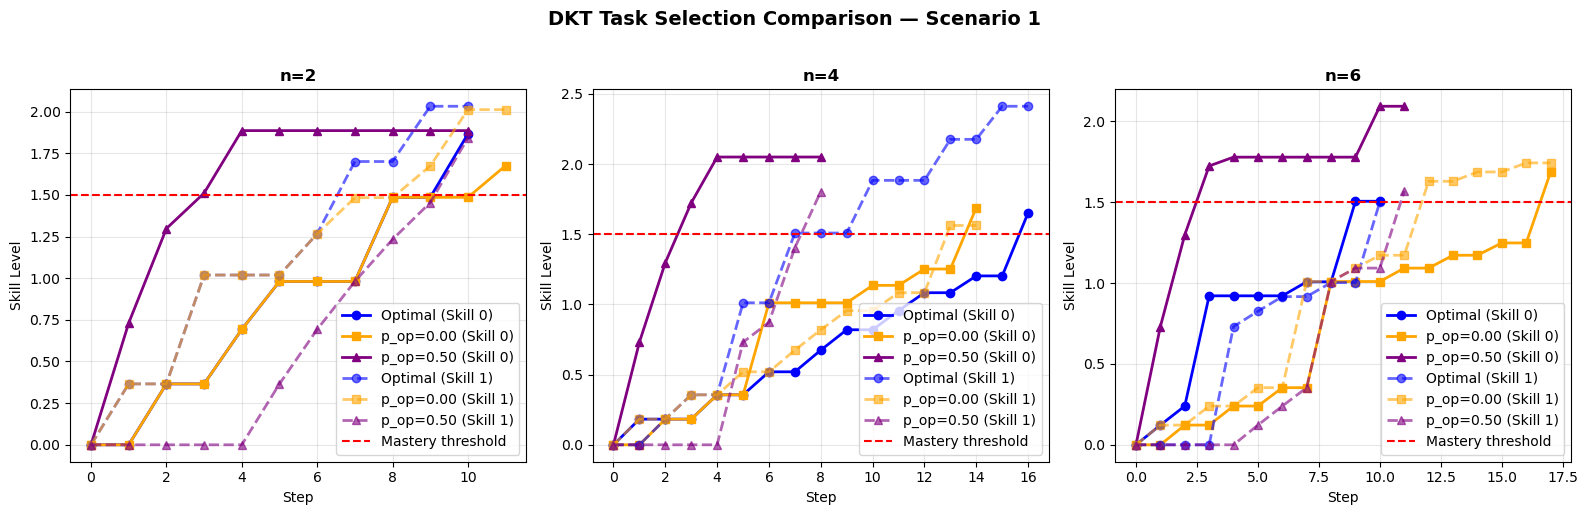

-------------- RESULTS FOR SCENARIO 2------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 1 prob 0.1496192216873169 prob everything tensor([0.2653, 0.1496])
[Student 0]: Selected Task 1 prob 0.012818311341106892 prob everything tensor([0.3080, 0.0128])
[Student 0]: Selected Task 1 prob 0.16102978587150574 prob everything tensor([0.4321, 0.1610])
[Student 0]: Selected Task 1 prob 0.011000012047588825 prob everything tensor([0.2850, 0.0110])
[Student 0]: Selected Task 0 prob 0.9546176195144653 prob everything tensor([0.9546, 0.9871])
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 0 prob 0.2653459906578064 prob everything tensor([0.2653, 0.1496])
[Student 0]: Selected Task 1 prob 0.20211245119571686 prob everything tensor([0.0173, 0.2021])
[Student 0]: Selected Task 0 prob 0.6054706573486328 prob everything tensor([0.6055, 0.0214])
[Student 0]: Selected Task 1 prob 0.5673312544822693 prob everything tensor([0.0194, 0.5

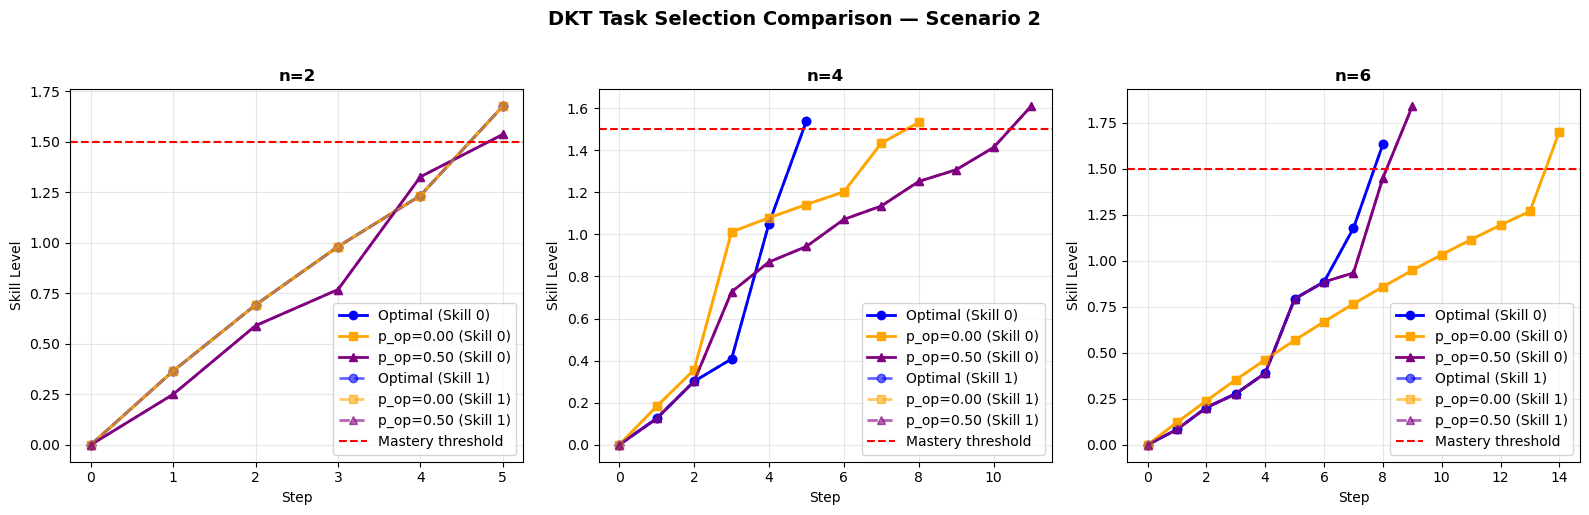

-------------- RESULTS FOR SCENARIO 3------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 3 prob 0.34582123160362244 prob everything tensor([0.5271, 0.5833, 0.3683, 0.3458])
[Student 0]: Selected Task 3 prob 0.40873438119888306 prob everything tensor([0.6058, 0.6510, 0.4141, 0.4087])
[Student 0]: Selected Task 2 prob 0.41672784090042114 prob everything tensor([0.6524, 0.7386, 0.4167, 0.4959])
[Student 0]: Selected Task 2 prob 0.44904837012290955 prob everything tensor([0.6803, 0.7366, 0.4490, 0.5045])
[Student 0]: Selected Task 2 prob 0.48205968737602234 prob everything tensor([0.7072, 0.7380, 0.4821, 0.5153])
[Student 0]: Selected Task 3 prob 0.5294639468193054 prob everything tensor([0.7706, 0.7167, 0.5773, 0.5295])
[Student 0]: Selected Task 2 prob 0.566405177116394 prob everything tensor([0.7851, 0.7736, 0.5664, 0.5869])
[Student 0]: Selected Task 2 prob 0.5792926549911499 prob everything tensor([0.7913, 0.7709, 0.5793, 0.586

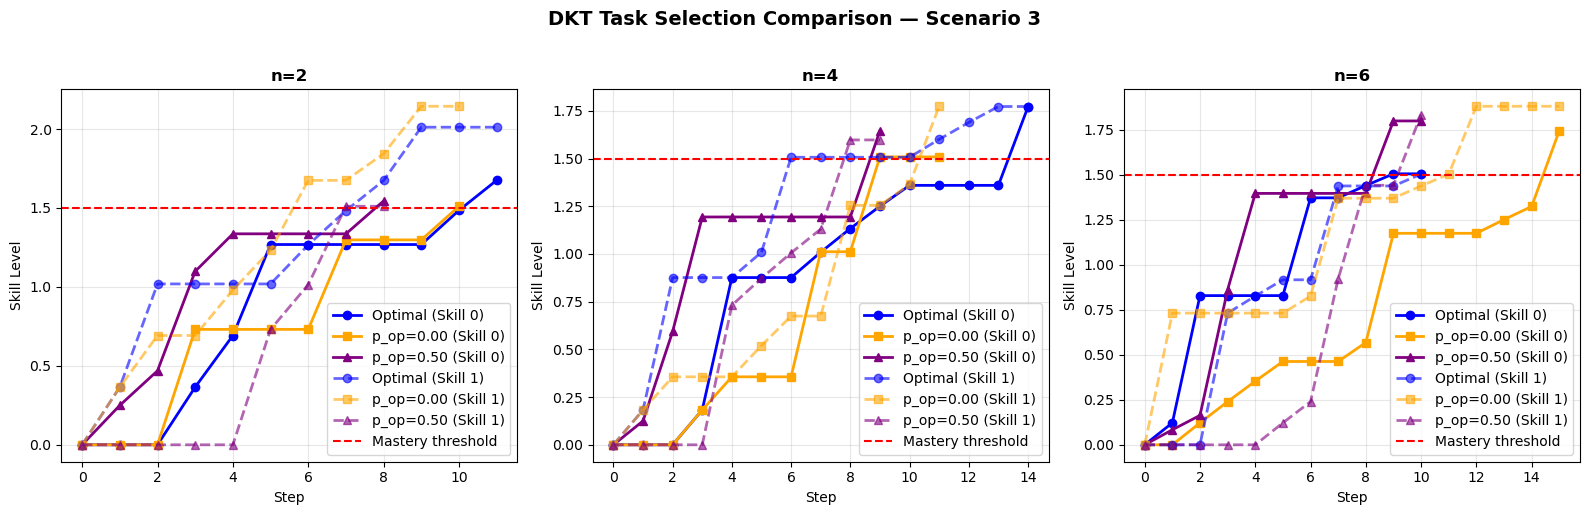

-------------- RESULTS FOR SCENARIO 4------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 3 prob 0.14698313176631927 prob everything tensor([0.3350, 0.3602, 0.1722, 0.1470])
[Student 0]: Selected Task 3 prob 0.017157239839434624 prob everything tensor([0.3093, 0.3393, 0.3243, 0.0172])
[Student 0]: Selected Task 3 prob 0.09048236161470413 prob everything tensor([0.3973, 0.3255, 0.2232, 0.0905])
[Student 0]: Selected Task 3 prob 0.01889604702591896 prob everything tensor([0.3283, 0.3528, 0.3338, 0.0189])
[Student 0]: Selected Task 3 prob 0.09372211992740631 prob everything tensor([0.4216, 0.3436, 0.2649, 0.0937])
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 0 prob 0.33498120307922363 prob everything tensor([0.3350, 0.3602, 0.1722, 0.1470])
[Student 0]: Selected Task 2 prob 0.34302204847335815 prob everything tensor([0.4499, 0.3142, 0.3430, 0.2069])
[Student 0]: Selected Task 3 prob 0.3355267643928528 prob everything

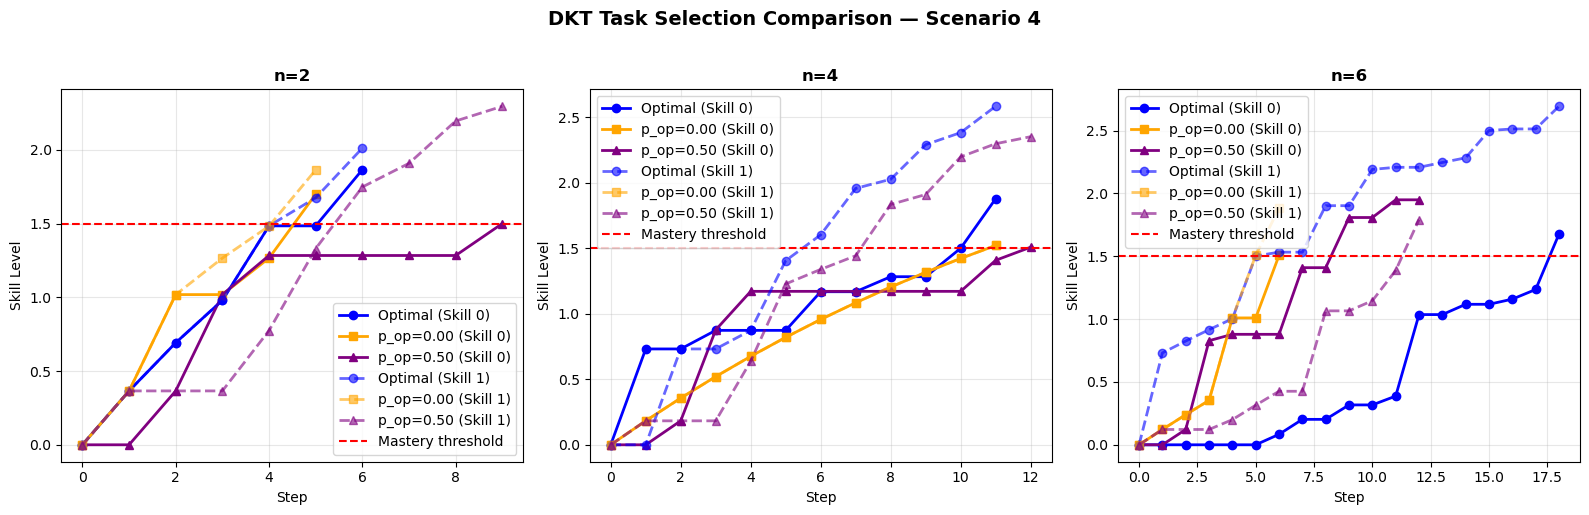

-------------- RESULTS FOR SCENARIO 5------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 5 prob 0.10267327725887299 prob everything tensor([0.5375, 0.5772, 0.2223, 0.3055, 0.3275, 0.1027])
[Student 0]: Selected Task 5 prob 0.017524590715765953 prob everything tensor([0.5507, 0.6392, 0.1179, 0.2963, 0.2984, 0.0175])
[Student 0]: Selected Task 5 prob 0.175552099943161 prob everything tensor([0.6517, 0.6785, 0.5864, 0.4451, 0.4253, 0.1756])
[Student 0]: Selected Task 5 prob 0.03565047308802605 prob everything tensor([0.7198, 0.7653, 0.2009, 0.4811, 0.3965, 0.0357])
[Student 0]: Selected Task 5 prob 0.44539156556129456 prob everything tensor([0.7880, 0.7759, 0.8576, 0.6457, 0.5375, 0.4454])
[Student 0]: Selected Task 5 prob 0.04731195792555809 prob everything tensor([0.7986, 0.8239, 0.2570, 0.5923, 0.4505, 0.0473])
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 4 prob 0.3274581730365753 prob everything tensor([0.5375, 

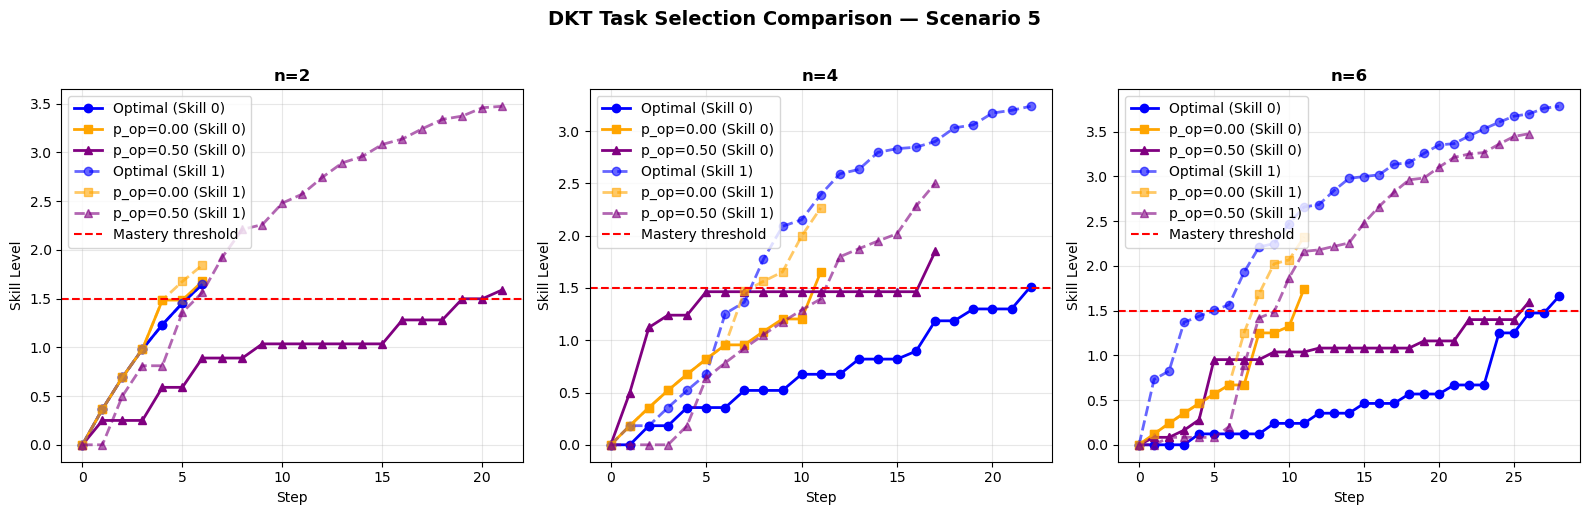

-------------- RESULTS FOR SCENARIO 6------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 5 prob 0.14532245695590973 prob everything tensor([0.5980, 0.5688, 0.3667, 0.3624, 0.2272, 0.1453])
[Student 0]: Selected Task 5 prob 0.16152754426002502 prob everything tensor([0.5059, 0.6577, 0.3238, 0.4379, 0.1619, 0.1615])
[Student 0]: Selected Task 4 prob 0.12230069935321808 prob everything tensor([0.4375, 0.7165, 0.2946, 0.5011, 0.1223, 0.1744])
[Student 0]: Selected Task 4 prob 0.1483171433210373 prob everything tensor([0.5228, 0.6518, 0.3154, 0.4415, 0.1483, 0.1558])
[Student 0]: Selected Task 5 prob 0.185794860124588 prob everything tensor([0.5775, 0.6528, 0.3661, 0.4410, 0.1887, 0.1858])
[Student 0]: Selected Task 4 prob 0.1755366027355194 prob everything tensor([0.4977, 0.7691, 0.3910, 0.5569, 0.1755, 0.2833])
[Student 0]: Selected Task 4 prob 0.2035876214504242 prob everything tensor([0.5054, 0.7843, 0.4172, 0.5713, 0.2036, 0.334

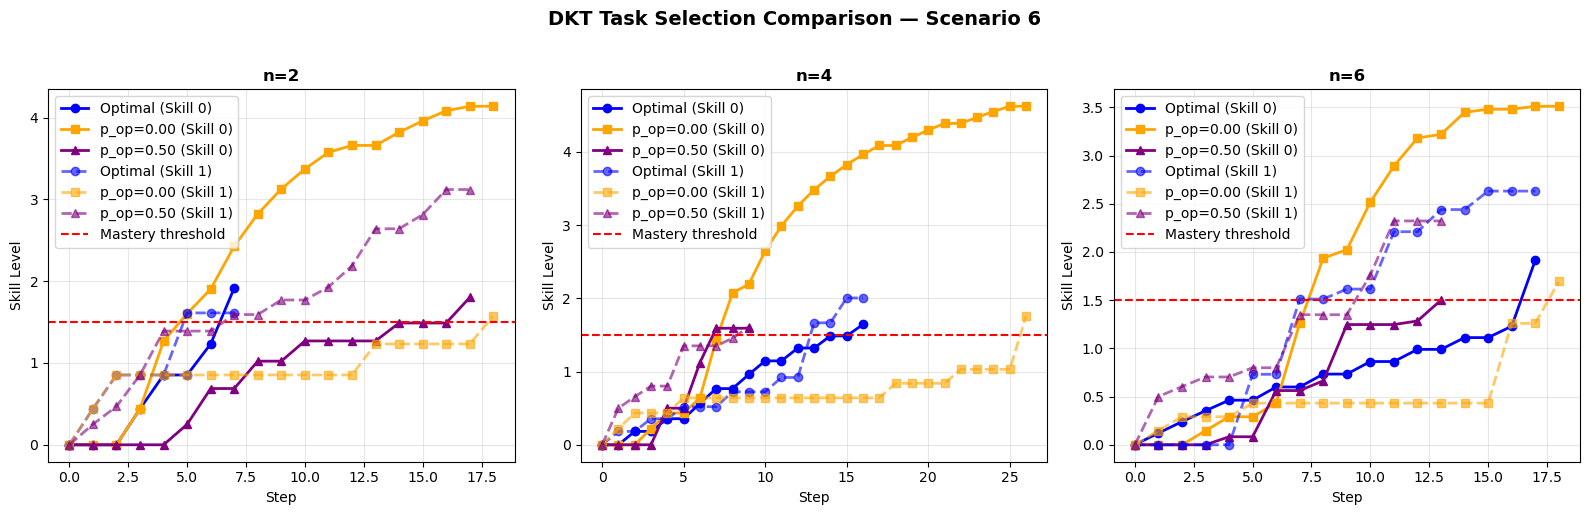

-------------- RESULTS FOR SCENARIO 7------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 7 prob 0.03601022809743881 prob everything tensor([0.0908, 0.4840, 0.1571, 0.5446, 0.0942, 0.1347, 0.4754, 0.0360])
[Student 0]: Selected Task 7 prob 0.006329888012260199 prob everything tensor([0.1382, 0.4710, 0.1514, 0.5893, 0.1802, 0.2030, 0.4159, 0.0063])
[Student 0]: Selected Task 7 prob 0.004855483770370483 prob everything tensor([0.1112, 0.4849, 0.2269, 0.6194, 0.1679, 0.2735, 0.4145, 0.0049])
[Student 0]: Selected Task 7 prob 0.0046197413466870785 prob everything tensor([0.1607, 0.5081, 0.2159, 0.6584, 0.2365, 0.2862, 0.4328, 0.0046])
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 6 prob 0.47537070512771606 prob everything tensor([0.0908, 0.4840, 0.1571, 0.5446, 0.0942, 0.1347, 0.4754, 0.0360])
[Student 0]: Selected Task 5 prob 0.27645984292030334 prob everything tensor([0.1638, 0.5324, 0.2023, 0.5795, 0.1987, 0.2765, 0

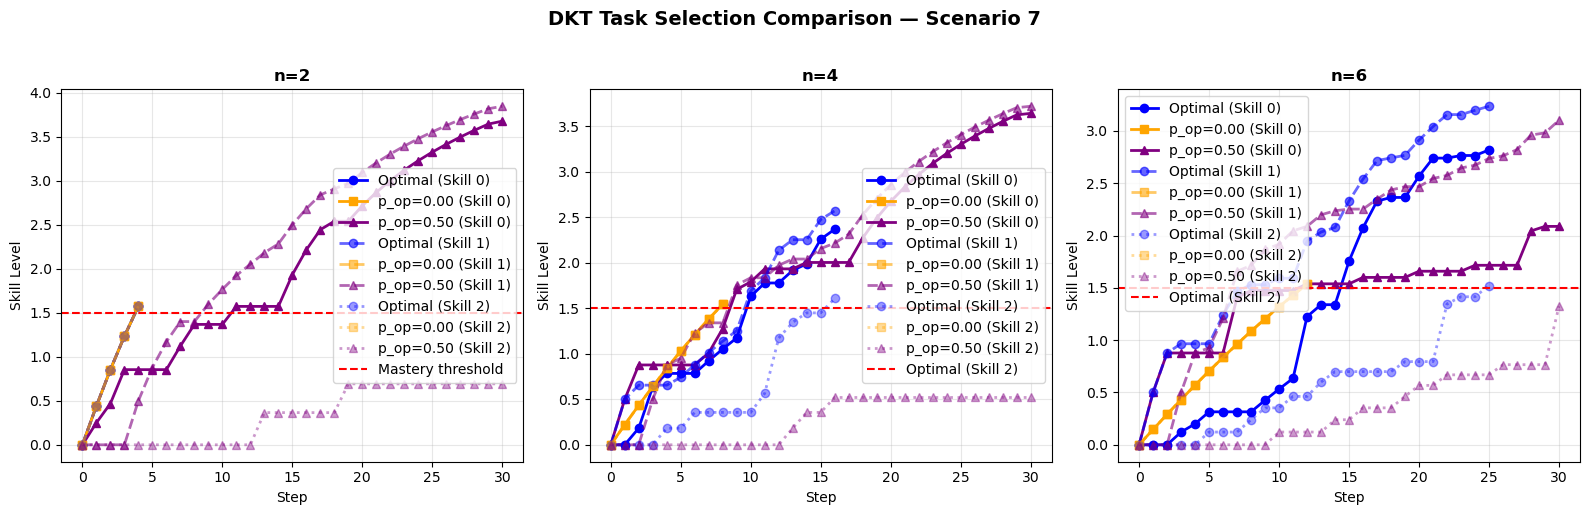

-------------- RESULTS FOR SCENARIO 8------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 6 prob 0.13832210004329681 prob everything tensor([0.6104, 0.5342, 0.4111, 0.4176, 0.2395, 0.2087, 0.1383, 0.1718])
[Student 0]: Selected Task 7 prob 0.08225110173225403 prob everything tensor([0.7179, 0.5497, 0.5110, 0.3329, 0.2251, 0.1415, 0.1093, 0.0823])
[Student 0]: Selected Task 7 prob 0.17371003329753876 prob everything tensor([0.7868, 0.6948, 0.5831, 0.4797, 0.3694, 0.2811, 0.2158, 0.1737])
[Student 0]: Selected Task 6 prob 0.2805432975292206 prob everything tensor([0.8010, 0.7767, 0.5644, 0.6102, 0.4366, 0.4155, 0.2805, 0.2968])
[Student 0]: Selected Task 7 prob 0.15327322483062744 prob everything tensor([0.8320, 0.7363, 0.6490, 0.4882, 0.4087, 0.2896, 0.2353, 0.1533])
[Student 0]: Selected Task 7 prob 0.3034655451774597 prob everything tensor([0.8347, 0.8049, 0.6259, 0.6255, 0.4968, 0.4524, 0.3327, 0.3035])
[Student 0]: Selected Ta

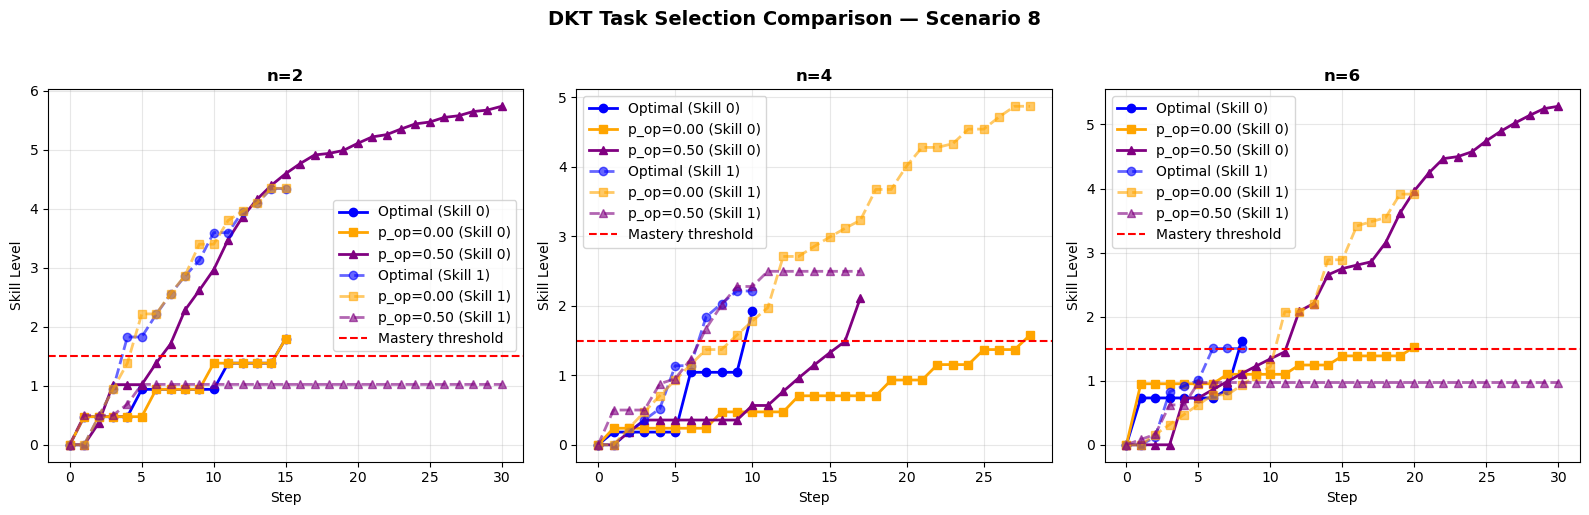

In [140]:
for scenario in scenarios:
        scenario_id    = scenario["id"]
        num_tasks      = scenario["num_tasks"]
        num_skills     = scenario["num_skills"]
        difficulty_level = np.array(scenario["difficulty_level"])
        q_matrix       = np.array(scenario["q_matrix"])
        depends = np.array(scenario["depends"])
        init_skill_level  = np.array([0.0] * num_skills)
        
        dkt, checkpoint = load_model(scenario_id, num_tasks)
            
        all_students_skill_dkt = []
        all_students_task_allocation_dkt = []
        
        print(f"-------------- RESULTS FOR SCENARIO {scenario_id}------------------")
        
        num_students_test = 50
        test_df = load_testing_data(scenario_id, "test")
        X_test, Y_test   = construct_training_data(test_df, 401, 450, num_tasks)
        print("OPTIMIZE TASK SELECTION METHOD")
        run_optimization(num_tasks)

# Your code here - all output will be saved to the file

In [141]:
import pandas as pd
import glob

files = sorted(glob.glob('Results/dkt_results_scenario_*.csv'))

df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Sort nicely by scenario, then n
df_all = df_all.sort_values(['scenario', 'n']).reset_index(drop=True)
# Write as a formatted plain-text table
with open('Results/dkt_results_combined.txt', 'w') as f:
    f.write(df_all.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print(df_all)

    scenario  n  p_op_optimal  steps_optimal_mean  steps_optimal_std  \
0          1  2      0.000000            9.000000           1.195229   
1          1  4      0.333333           11.346939           2.607298   
2          1  6      0.400000           11.877551           3.074800   
3          2  2      0.000000            5.387755           0.564831   
4          2  4      0.333333            8.775510           1.919453   
5          2  6      0.400000            8.897959           2.674482   
6          3  2      0.000000            8.673469           1.376001   
7          3  4      0.333333           10.632653           1.996874   
8          3  6      0.400000           11.693878           2.786294   
9          4  2      0.000000            5.632653           0.629022   
10         4  4      0.333333           10.163265           2.605700   
11         4  6      0.400000           14.571429           3.307382   
12         5  2      0.000000            5.591837           0.63